In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from joblib import dump

In [10]:


data = pd.read_csv("collected_features.csv") 

# Вывод первых 5 строк
print(data.head())

   label  all_landmarks_visible  thumb_extended  index_extended  \
0      0                      1               1               1   
1      0                      1               1               1   
2      0                      1               1               1   
3      0                      1               1               1   
4      0                      1               1               1   

   middle_extended  ring_extended  pinky_extended  wrist_dx_t0  wrist_dy_t0  \
0                1              1               1     -0.00071      0.41823   
1                1              1               1      0.05401     -0.03050   
2                1              1               1      0.08395     -0.06670   
3                1              1               1     -0.01198     -0.03079   
4                1              1               1     -0.03064      0.00855   

   wrist_vx_t0  ...  wrist_vx_t2  wrist_vy_t2  wrist_ax_t2  wrist_ay_t2  \
0      0.04317  ...     -0.14200      0.36392  

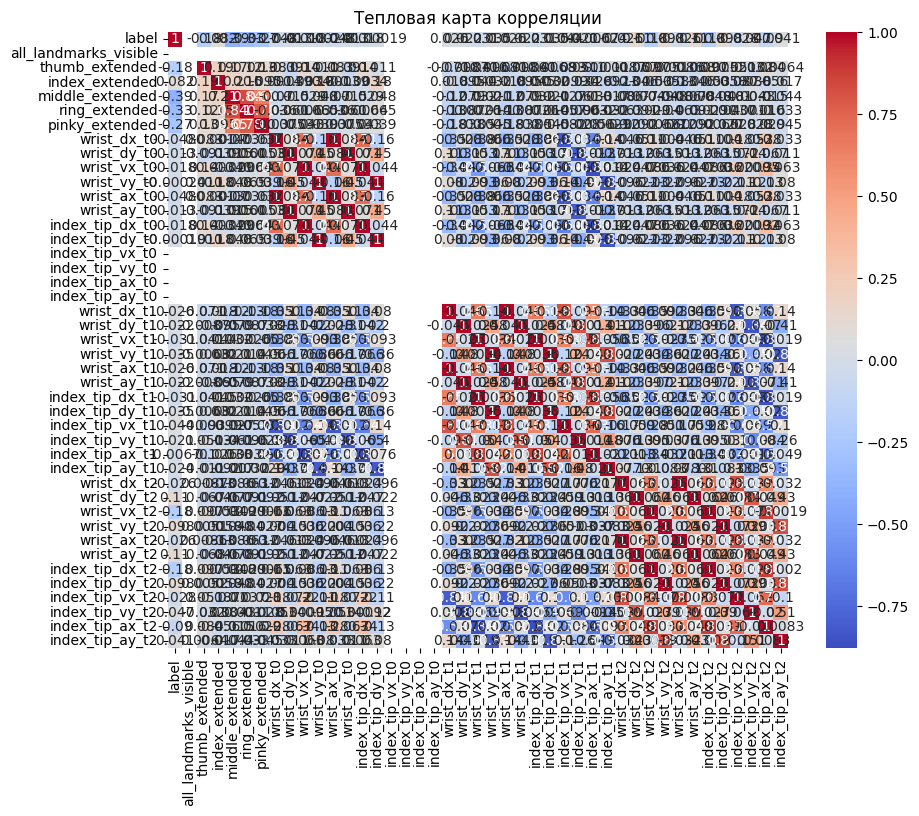

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Тепловая карта корреляции")
plt.show()

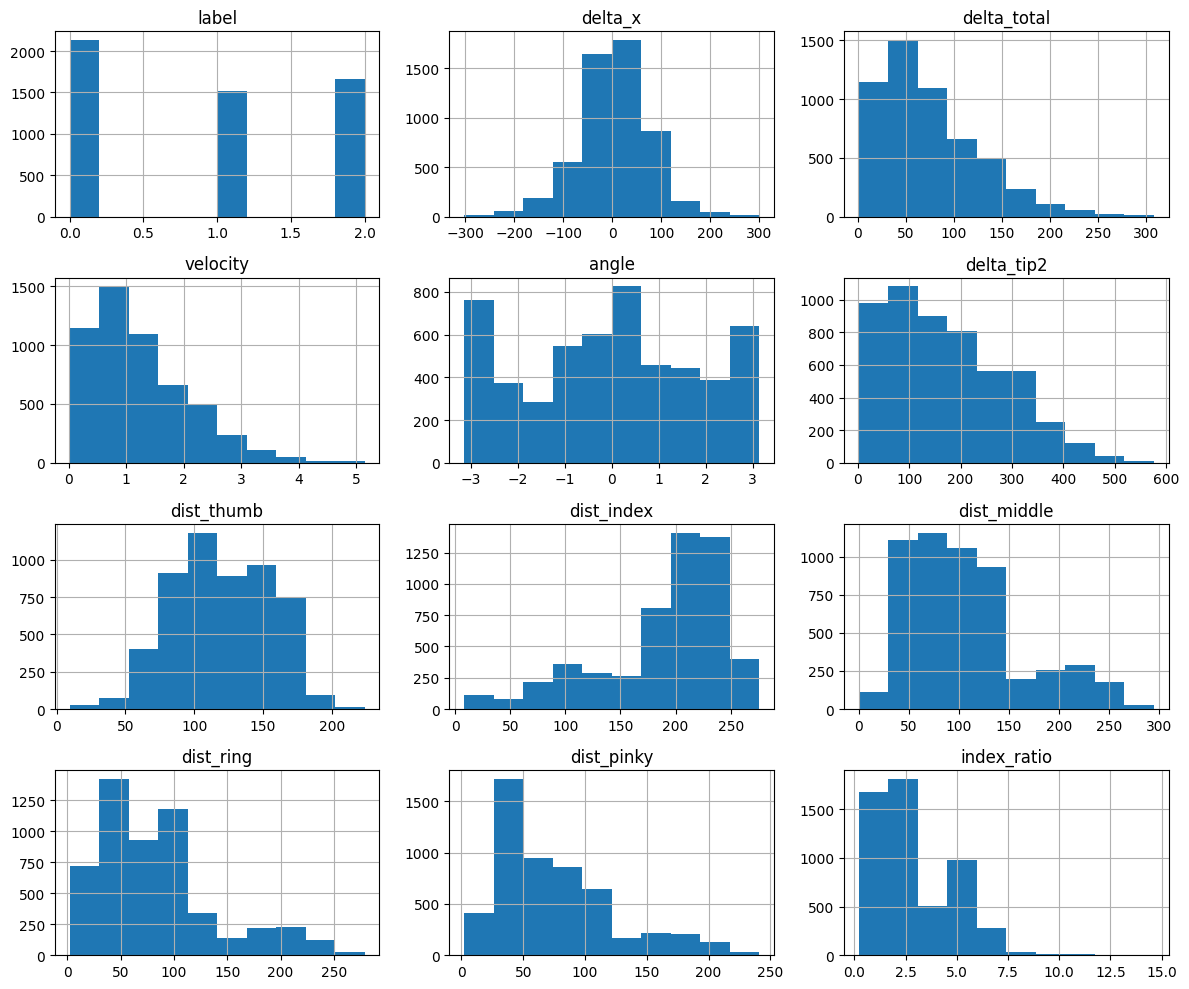

In [16]:
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

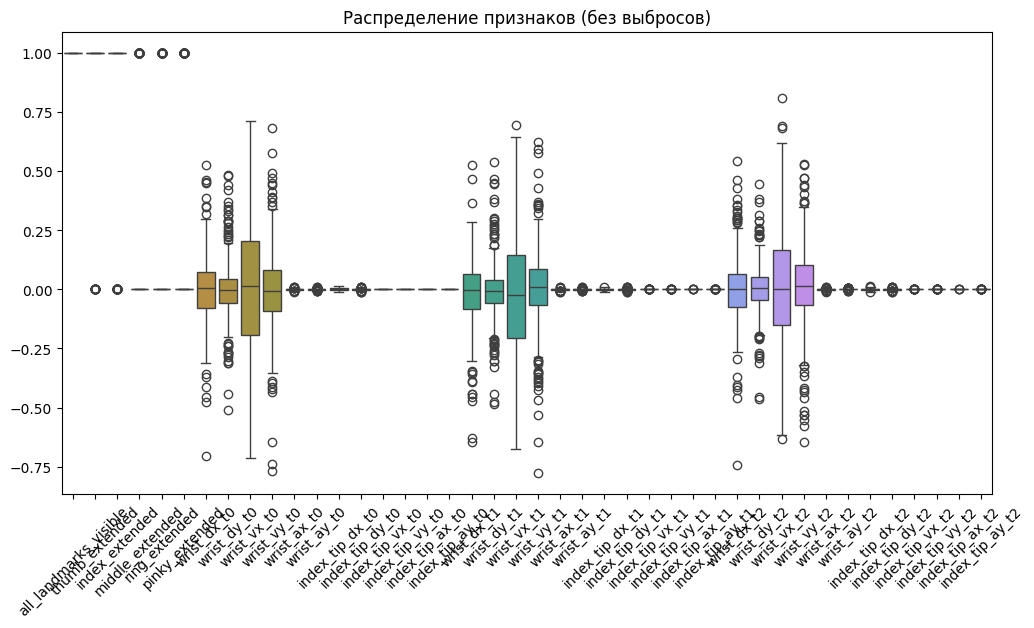

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.drop('label', axis=1))
plt.xticks(rotation=45)
plt.title("Распределение признаков (без выбросов)")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Разделение данных
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

              precision    recall  f1-score   support

           0       0.69      0.88      0.77        56
           1       0.40      0.12      0.18        17
           2       0.73      0.61      0.67        18

    accuracy                           0.68        91
   macro avg       0.61      0.53      0.54        91
weighted avg       0.64      0.68      0.64        91

Accuracy: 0.68


In [14]:
# Шаг 1: Взвешивание классов
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Шаг 2: Подбор параметров для улучшенной модели
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)

# Итоговый отчёт
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85        56
           1       0.57      0.47      0.52        17
           2       0.68      0.83      0.75        18

    accuracy                           0.77        91
   macro avg       0.70      0.71      0.70        91
weighted avg       0.77      0.77      0.77        91



In [15]:
# Сохранение
dump(model, 'model.joblib')

['model.joblib']